In [20]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from scipy.optimize import minimize_scalar

In [21]:
# Set magics
# use autoreload to only reload the user-written functions 
%load_ext autoreload
%autoreload 1

%aimport model 

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [23]:
eps = 0.1
s = 0.25

sol = model.solve_equilibrium(eps, s)

print("Equilibrium:", sol)

check = model.check_interior(sol["p1"], sol["p2"], eps, s)

print("Interior check:", check)

Equilibrium: {'p1': 0.5353620069352739, 'p2': 0.4873334833516168, 'converged': True, 'iterations': 2}
Interior check: {'z_positive': True, 'theta_interior': True, 'support_ok': True, 'interior': True}


In [38]:
eps_grid = np.linspace(0.0, 0.5, 25)   # preference strength
s_grid   = np.linspace(0.001, 0.25, 25) # search cost (avoid 0 exactly)
results = []

In [39]:
prev_p1, prev_p2 = 0.5, 0.5

for eps in eps_grid:
    for s in s_grid:
        
        try:
            p1, p2, converged = model.solve_equilibrium(
                eps, s,
                p1_init=prev_p1,
                p2_init=prev_p2
            )
            
            # update warm start
            prev_p1, prev_p2 = p1, p2
            
            # compute objects
            theta = model.theta_star(p1, p2, eps, s)
            interior = model.check_interior(p1, p2, eps, s)["interior"]
            
            results.append({
                "eps": eps,
                "s": s,
                "p1": p1,
                "p2": p2,
                "theta": theta,
                "interior": interior,
                "converged": converged
            })
        
        except Exception as e:
            results.append({
                "eps": eps,
                "s": s,
                "p1": np.nan,
                "p2": np.nan,
                "theta": np.nan,
                "interior": False,
                "converged": False
            })

In [40]:
df = pd.DataFrame(results)
df["theta"] = df["theta"].clip(0, 1)
p1_mat = df.pivot(index="s", columns="eps", values="p1")
p2_mat = df.pivot(index="s", columns="eps", values="p2")
theta_mat = df.pivot(index="s", columns="eps", values="theta")
interior_mat = df.pivot(index="s", columns="eps", values="interior")

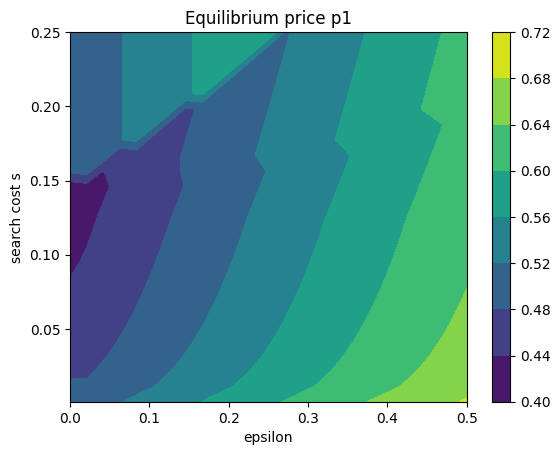

In [41]:
plt.figure()
plt.contourf(eps_grid, s_grid, p1_mat.values)
plt.colorbar()
plt.title("Equilibrium price p1")
plt.xlabel("epsilon")
plt.ylabel("search cost s")
plt.show()

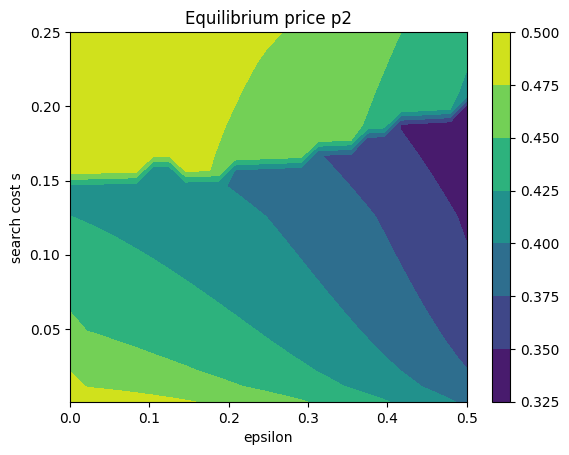

In [42]:
plt.figure()
plt.contourf(eps_grid, s_grid, p2_mat.values)
plt.colorbar()
plt.title("Equilibrium price p2")
plt.xlabel("epsilon")
plt.ylabel("search cost s")
plt.show()

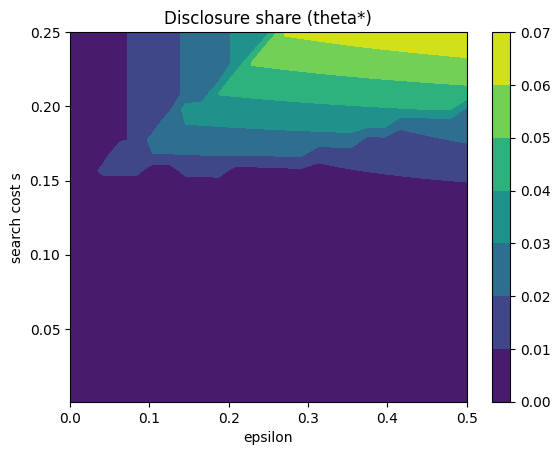

In [43]:
plt.figure()
plt.contourf(eps_grid, s_grid, theta_mat.values)
plt.colorbar()
plt.title("Disclosure share (theta*)")
plt.xlabel("epsilon")
plt.ylabel("search cost s")
plt.show()

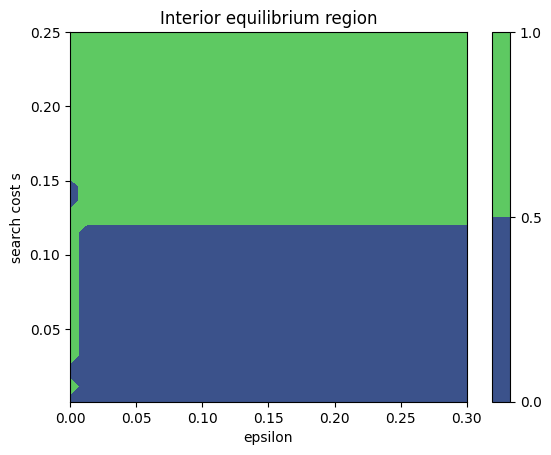

In [37]:
plt.figure()
plt.contourf(eps_grid, s_grid, interior_mat.values)
plt.colorbar()
plt.title("Interior equilibrium region")
plt.xlabel("epsilon")
plt.ylabel("search cost s")
plt.show()